In [13]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
PACKAGE_USED = 0  # 0 = sklearn; 1 = sktime; 2 = aeon

In [15]:
APPROACH = "svm"

In [16]:
CHANNEL_CONFIG = "g-a"

In [17]:
DATA_DIR = [
    R"dataset_30hz"
]

# Build DataFrame

In [18]:
def build_df(dirs):
    all_csv_files = []

    for _DIR in dirs:
        file_pattern = os.path.join(_DIR, "*.csv")
        csv_files = glob.glob(file_pattern)
        print(f"{_DIR} -> {len(csv_files)} CSV files found")
        all_csv_files.extend(csv_files)

    print(f"A total of {len(all_csv_files)} CSV files were used in constructing this DataFrame.")

    if not all_csv_files:
        raise ValueError("No CSV files found in the provided directories.")

    df = pd.concat((pd.read_csv(f) for f in all_csv_files), ignore_index=True)
    return df

In [19]:
from sklearn.model_selection import train_test_split

df_all = build_df(DATA_DIR)
df_all.drop_duplicates(inplace=True)

df_train, df_test = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all["motion_type"]
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Train size: {len(df_train)}")
print(f"Test size: {len(df_test)}")

dataset_30hz -> 93 CSV files found
A total of 93 CSV files were used in constructing this DataFrame.
Train size: 7944
Test size: 1986


In [20]:
# Verify
print("=== TRAIN motion_type counts ===")
print(df_train["motion_type"].value_counts().sort_index())

print("\n=== TEST motion_type counts ===")
print(df_test["motion_type"].value_counts().sort_index())

=== TRAIN motion_type counts ===
motion_type
FAN            914
HIT            872
LIFT           869
POUR           917
SHAKE          842
SPIN           873
STIR           893
SWING_LEFT     910
SWING_RIGHT    854
Name: count, dtype: int64

=== TEST motion_type counts ===
motion_type
FAN            229
HIT            218
LIFT           217
POUR           230
SHAKE          210
SPIN           218
STIR           223
SWING_LEFT     228
SWING_RIGHT    213
Name: count, dtype: int64


In [21]:
print(df_train.duplicated().sum())

0


In [22]:
print(df_test.duplicated().sum())

0


## Remove unneeded columns

In [23]:
match CHANNEL_CONFIG:
    case "gyro":
        df_train = df_train.filter(regex=r'^(gyro|motion)')
        df_test = df_test.filter(regex=r'^(gyro|motion)')
    case "accel":
        df_train = df_train.filter(regex=r'^(acc|motion)')
        df_test = df_test.filter(regex=r'^(acc|motion)')
    case "mag":
        df_train = df_train.filter(regex=r'^(mag|motion)')
        df_test = df_test.filter(regex=r'^(mag|motion)')
    case "ahrs":
        df_train = df_train.filter(regex=r'^(ahrs|motion)')
        df_test = df_test.filter(regex=r'^(ahrs|motion)')
    case "g-a":
        df_train = df_train.filter(regex=r'^(gyro|acc|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|motion)')
    case "g-m":
        df_train = df_train.filter(regex=r'^(gyro|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|mag|motion)')
    case "a-m":
        df_train = df_train.filter(regex=r'^(acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(acc|mag|motion)')
    case "g-a-m":
        df_train = df_train.filter(regex=r'^(gyro|acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|mag|motion)')
    case _:
        pass

In [24]:
# df_train = df_train.drop(df_train[df_train["motion_type"] == "POUR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_UP"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_DOWN"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "STIR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "ROLL"].index)


In [25]:
df_train.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14,motion_type
0,2.307857,1.560104,1.822768,2.378410,-1.200697,-3.902550,-3.497864,-0.200358,1.561326,2.597094,...,-9.375977,13.019647,28.051359,24.928726,10.624432,-3.941876,-20.488245,-20.767008,-13.815859,STIR
1,-1.597364,-1.375789,-2.294580,-3.017362,-1.737979,3.522830,3.598996,1.758219,4.939631,2.070874,...,6.217742,15.263036,9.327810,7.977480,0.464475,10.402806,16.809690,6.888118,8.853758,SWING_LEFT
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000137,-0.731637,-1.914137,-1.979725,...,-2.344050,-16.711950,-13.135051,36.937950,-23.040001,-5.551950,-5.715000,-12.289950,-10.891050,SPIN
3,-0.142450,-0.293150,-0.105462,0.780450,3.515188,9.053963,23.609713,14.066525,-0.209413,0.568425,...,-6.609000,-6.403050,1.765050,-4.866000,-3.654000,10.320001,-1.306950,-1.033950,-0.151950,HIT
4,0.332363,0.197074,0.061253,-0.200802,-2.238121,-3.091398,-2.345180,1.247425,1.601625,2.216283,...,7.589619,5.702989,0.818817,5.291186,-5.324705,4.225766,1.941698,2.003947,1.144428,HIT


In [26]:
df_test.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14,motion_type
0,0.100512,-0.003300,-0.399163,-0.842600,-0.839025,-0.836550,-1.488987,-2.498100,-1.194463,0.730950,...,3.324000,22.707001,50.095951,35.215054,25.533001,22.561050,13.156951,6.141000,0.586950,FAN
1,-0.637450,-0.680212,-1.071125,-1.150600,-1.040600,-0.383350,-0.176825,-0.123062,0.693000,4.431488,...,0.447000,-0.522000,19.527000,33.430950,13.563001,14.776951,3.937950,-3.100050,-8.418000,LIFT
2,0.602407,1.003479,0.625310,0.373908,0.394680,0.201868,-3.547863,-0.211988,-1.035970,0.640224,...,-21.006725,-8.844181,6.447585,-11.276690,0.567426,0.481235,-0.596156,-0.699107,-1.328782,HIT
3,-0.067787,-0.024338,0.324912,0.956312,-0.117700,-1.346812,-0.102300,0.578188,-3.641000,-14.864162,...,14.310000,19.977001,-33.414001,3.223950,-9.739950,-15.483001,-11.859000,-5.413950,-8.559000,SPIN
4,0.710050,-0.035200,0.227563,0.416900,-0.208587,-0.280775,-0.267300,0.283662,-0.619162,-0.256300,...,-4.900950,14.427001,43.908001,42.522003,35.587952,24.718052,16.840950,11.431951,1.069950,FAN


C:\Users\samue\AppData\Local\Temp\ipykernel_34984\1258022319.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distribusi, x='Nama Gestur', y='Jumlah Sampel', palette='viridis')


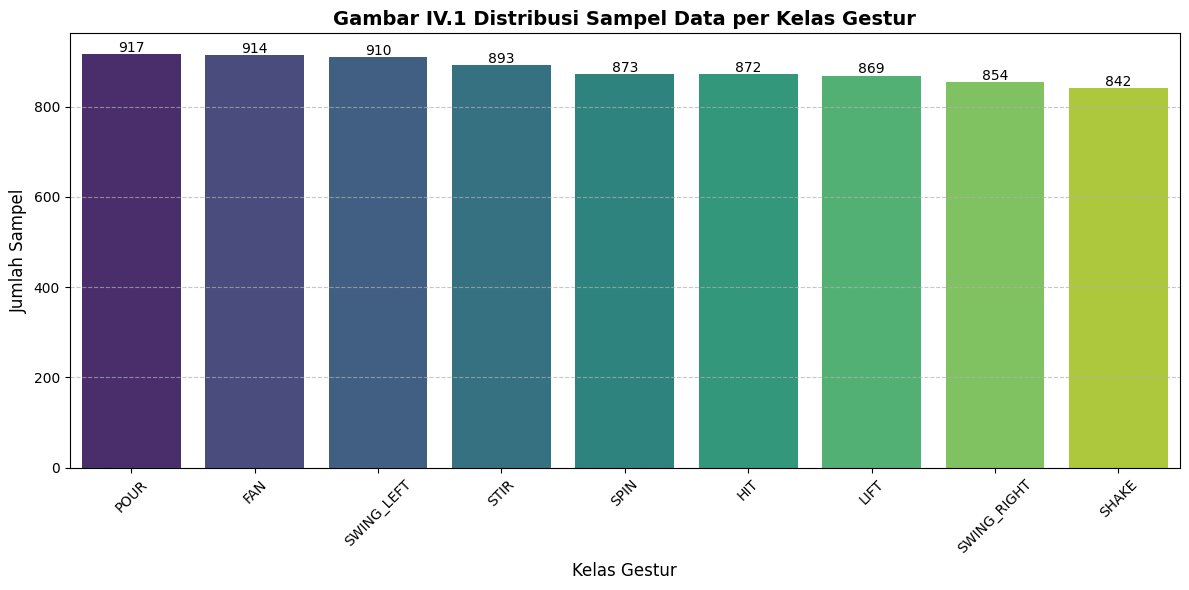

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

distribusi = df_train['motion_type'].value_counts().reset_index()
distribusi.columns = ['Nama Gestur', 'Jumlah Sampel']

plt.figure(figsize=(12, 6))
sns.barplot(data=distribusi, x='Nama Gestur', y='Jumlah Sampel', palette='viridis')
plt.title('Gambar IV.1 Distribusi Sampel Data per Kelas Gestur', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Gestur', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in distribusi.iterrows():
    plt.text(index, row['Jumlah Sampel'] + 5, str(row['Jumlah Sampel']), color='black', ha="center")

plt.tight_layout()
plt.show()

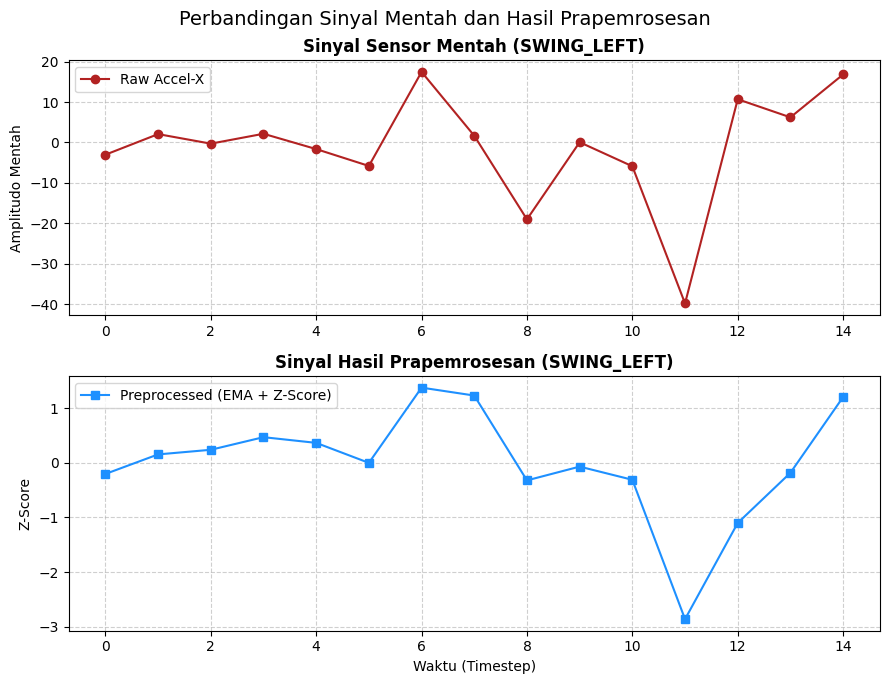

In [28]:
from scipy.stats import zscore

LABEL_NAME = 'SWING_LEFT'
sample_data = df_train[df_train['motion_type'] == LABEL_NAME].iloc[0]

timesteps = 15
acc_x_raw = [sample_data[f'acc_x_{i}'] for i in range(timesteps)]

# Preprocessing
# 1. Low-Pass Filter (Exponential Moving Average)
def ema_filter(data, alpha=0.3):
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[i-1])
    return ema

acc_x_ema = ema_filter(acc_x_raw, alpha=0.3)

# 2. Standarization
acc_x_prep = zscore(acc_x_ema)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(9, 7))

# Plot Atas: Sinyal Mentah
axes[0].plot(acc_x_raw, marker='o', color='firebrick', label='Raw Accel-X')
axes[0].set_title(f"Sinyal Sensor Mentah ({LABEL_NAME})", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Amplitudo Mentah")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot Bawah: Sinyal Preprocessed
axes[1].plot(acc_x_prep, marker='s', color='dodgerblue', label='Preprocessed (EMA + Z-Score)')
axes[1].set_title(f"Sinyal Hasil Prapemrosesan ({LABEL_NAME})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Waktu (Timestep)")
axes[1].set_ylabel("Z-Score")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.suptitle("Perbandingan Sinyal Mentah dan Hasil Prapemrosesan", y=0.97, fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# sns.countplot(df_train, x="motion_type", hue="motion_type")

In [30]:
len(df_train)

7944

In [31]:
# sns.countplot(df_test, x="motion_type", hue="motion_type")

In [32]:
len(df_test)

1986

## Get X and y

In [33]:
from sklearn.preprocessing import LabelEncoder

In [34]:
def get_X_and_y(df: pd.DataFrame, package_used: int) -> tuple[np.array, np.array]:
    if package_used == 0:  # sklearn
        X = df.drop(columns=["motion_type"]).values
        y = df["motion_type"].values
        return X.astype("float32"), y
    
    elif package_used == 1:  # sktime
        X_df = df.drop(columns=["motion_type"])
        y = df["motion_type"].values
        
        n_timesteps = 30
        channels = []
        match CHANNEL_CONFIG:
            case "accel":
                channels = ["accel_x", "accel_y", "accel_z"]
            case "gyro":
                channels = ["gyro_x", "gyro_y", "gyro_z"]
            case "mag":
                channels = ["mag_x", "mag_y", "mag_z"]
            case "ahrs":
                channels = ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
            case "g-a":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
            case "g-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
            case "a-m":
                channels = ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case "g-a-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case _:
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z", "ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
        n_channels = len(channels)

        X = np.zeros((len(df), n_channels, n_timesteps))

        for t in range(n_timesteps):
            for c, channel in enumerate(channels):
                col_name = f"{channel}_{t}"
        
                X[:, c, t] = X_df[col_name].values
                
        return X.astype("float32"), y

    else:  # aeon
        y = df["motion_type"].values

        n_timesteps = 30

        channels = {
            "accel": ["accel_x", "accel_y", "accel_z"],
            "gyro": ["gyro_x", "gyro_y", "gyro_z"],
            "mag": ["mag_x", "mag_y", "mag_z"],
            "ahrs": ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"],
            "g-a": ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"],
            "g-m": ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"],
            "a-m": ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"],
            "g-a-m": ["gyro_x", "gyro_y", "gyro_z",
                    "accel_x", "accel_y", "accel_z",
                    "mag_x", "mag_y", "mag_z"],
        }.get(CHANNEL_CONFIG, [
            "gyro_x","gyro_y","gyro_z",
            "accel_x","accel_y","accel_z",
            "mag_x","mag_y","mag_z",
            "ahrs_x","ahrs_y","ahrs_z","ahrs_w"
        ])

        n_channels = len(channels)
        X = np.zeros((len(df), n_channels, n_timesteps), dtype="float32")

        for t in range(n_timesteps):
            for c, ch in enumerate(channels):
                X[:, c, t] = df[f"{ch}_{t}"].values

        return X.astype("float32"), y

In [35]:
X_train, y_train = get_X_and_y(df_train, PACKAGE_USED)
X_test, y_test = get_X_and_y(df_test, PACKAGE_USED)

In [36]:
X_train.shape

(7944, 90)

In [37]:
y_train

array(['STIR', 'SWING_LEFT', 'SPIN', ..., 'SWING_RIGHT', 'SWING_LEFT',
       'HIT'], shape=(7944,), dtype=object)

In [38]:
mapping = {'HIT': 0, 'SHAKE': 1, 'SWING_LEFT': 2, 'SWING_RIGHT': 3, 'FAN': 4, 'IDLE': 5, 'STIR': 6, 'LIFT': 7, 'SPIN': 8, 'POUR': 9}
y_train = np.vectorize(mapping.get)(y_train)
y_test = np.vectorize(mapping.get)(y_test)

In [39]:
unk_train = set(y_train) - set(mapping.keys())
print(f"Unknown labels in y_train: {unk_train}")

Unknown labels in y_train: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [40]:
# from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
# from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
from aeon.classification.deep_learning import LITETimeClassifier

In [41]:
if PACKAGE_USED == 0:
    if APPROACH.lower() == "svm":
        clf_minirocket = SVC()
    elif APPROACH.lower() == "rf":
        clf_minirocket = RandomForestClassifier()
    elif APPROACH.lower() == "softmax":
        clf_minirocket = LogisticRegression(solver = "saga", max_iter=1000)

In [42]:
if PACKAGE_USED == 1:
    if APPROACH.lower() == "knn":
        clf_minirocket = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
    elif APPROACH.lower() == "minirocket":
        clf_minirocket = make_pipeline(
            MiniRocketMultivariate(random_state=42),
            RidgeClassifier(alpha=1.0)
        )

In [43]:
if PACKAGE_USED == 2:
    if APPROACH.lower() == "litemvtime":
        clf_minirocket = LITETimeClassifier(use_litemv=True)

In [44]:
clf_minirocket.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [46]:
y_pred_train = clf_minirocket.predict(X_train)

In [47]:
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average="weighted"))
print(recall_score(y_train, y_pred_train, average="weighted"))
print(f1_score(y_train, y_pred_train, average="weighted"))

0.9939577039274925
0.9939976244361859
0.9939577039274925
0.993963955126227


In [48]:
y_pred_test = clf_minirocket.predict(X_test)

In [49]:
print(accuracy_score(y_test, y_pred_test))
print(precision_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(recall_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(f1_score(y_test, y_pred_test, average="weighted", zero_division=0))

0.9894259818731118
0.9895248977033424
0.9894259818731118
0.9894353204389974


In [50]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

[[218   0   0   0   0   0   0   0   0]
 [  0 207   0   0   0   0   0   1   2]
 [  0   0 227   0   0   0   0   0   1]
 [  0   0   0 212   0   0   0   1   0]
 [  1   0   0   0 226   0   0   2   0]
 [  1   0   0   0   1 218   1   2   0]
 [  0   1   0   0   0   3 212   0   1]
 [  0   0   0   0   0   0   0 217   1]
 [  0   0   0   0   0   0   1   1 228]]


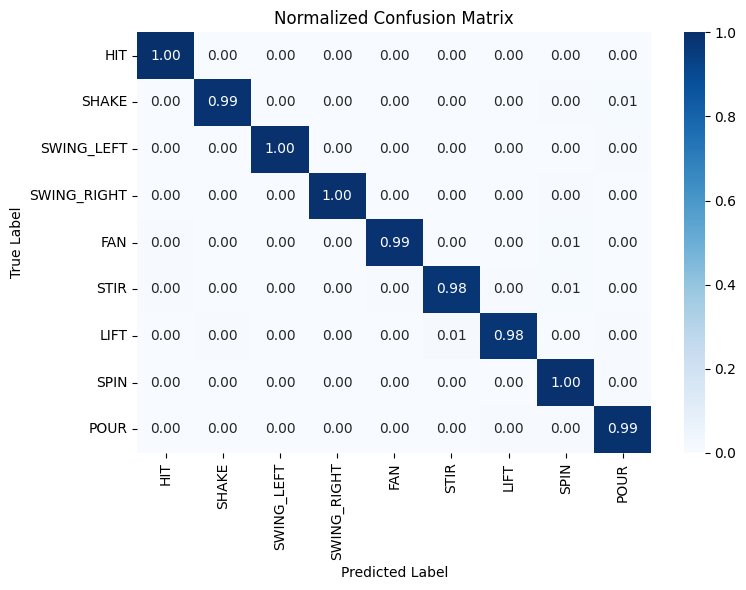

In [62]:
from sklearn.preprocessing import LabelEncoder

# Invert the mapping dict: {0: 'HIT', 1: 'SHAKE', ...}
inverse_mapping = {v: k for k, v in mapping.items()}

# Get the labels actually present in y_test, in sorted order
present_labels = sorted(np.unique(y_test))

# Map each integer label back to its motion name
class_names = [inverse_mapping[i] for i in present_labels]

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"cmat_{APPROACH}.png")
plt.show()

In [52]:
from sklearn.metrics import classification_report

In [53]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       218
           1       1.00      0.99      0.99       210
           2       1.00      1.00      1.00       228
           3       1.00      1.00      1.00       213
           4       1.00      0.99      0.99       229
           6       0.99      0.98      0.98       223
           7       0.99      0.98      0.98       217
           8       0.97      1.00      0.98       218
           9       0.98      0.99      0.98       230

    accuracy                           0.99      1986
   macro avg       0.99      0.99      0.99      1986
weighted avg       0.99      0.99      0.99      1986



In [54]:
from time import perf_counter

In [55]:
t0 = perf_counter()
a = clf_minirocket.predict(X_train[0:1])
t1 = perf_counter()

In [56]:
print(f"{t1 - t0} seconds taken to perform a single inference!")

0.0006037000130163506 seconds taken to perform a single inference!


In [57]:
from skl2onnx import to_onnx

if PACKAGE_USED == 0:
    onx = to_onnx(clf_minirocket, X_train[:1])
    with open(f"clf_{APPROACH}_ori.onnx", "wb") as f:
        f.write(onx.SerializeToString())

In [58]:
from joblib import dump

dump(clf_minirocket, f"clf_{APPROACH}_ori.joblib")

['clf_svm_ori.joblib']

In [59]:
# clf_minirocket.predict(X_train[0:1])

In [60]:
# print(repr(X_train[0:1]))

In [61]:
# print(repr(y_train[0]))